In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import os

In [6]:

os.chdir('C:/Users/p528552/OneDrive - South African Reserve Bank/Documents/1. MEng - Data Science/1. Project_2025/Data/factor_timing/data_input')

In [7]:


# ===========================
# LOAD DATA
# ===========================


preds = pd.read_csv("log_momentum_quality_probs.csv", parse_dates=['Date'])
#preds = preds.set_index('Date')


rets = pd.read_csv("cum_relative_factor_returns.csv", parse_dates=['Date'])
#rets = rets.set_index('Date')

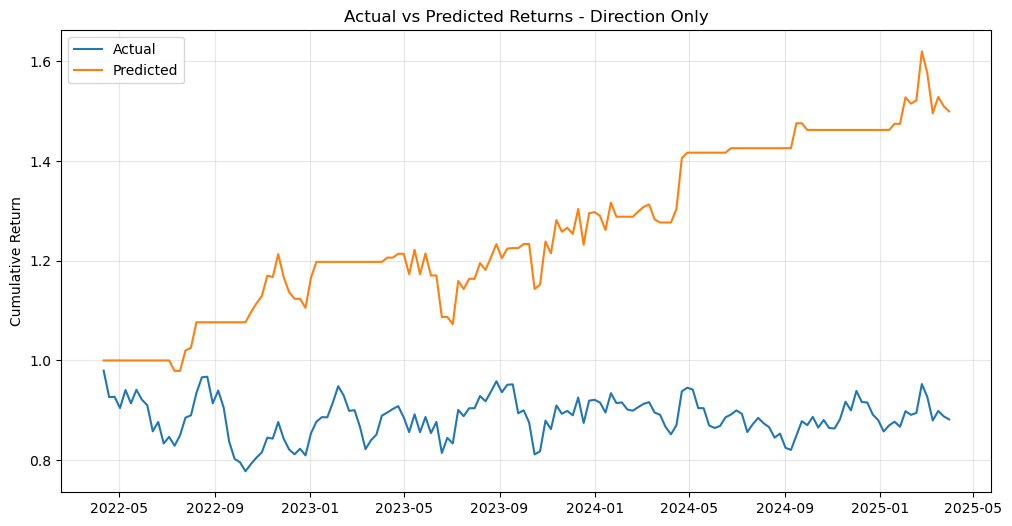

In [9]:


# ===========================
# MERGE ON DATE
# ===========================
df = preds.merge(rets, on="Date", how="inner")

# ===========================
# ACTUAL WEEKLY RETURN
# ===========================
df["actual_return"] = df["Momentum_vs_Quality"]

# ===========================
# PREDICTED RETURN (DIRECTION ONLY)
# prediction = 1 → take return
# prediction = 0 → take negative return
# ===========================
df["predicted_return"] = df["prediction"] * df["Momentum_vs_Quality"]

# ===========================
# CUMULATIVE RETURNS
# ===========================
df["actual_cum"] = (1 + df["actual_return"]).cumprod()
df["predicted_cum"] = (1 + df["predicted_return"]).cumprod()

# ===========================
# PLOT
# ===========================
plt.figure(figsize=(12,6))
plt.plot(df["Date"], df["actual_cum"], label="Actual")
plt.plot(df["Date"], df["predicted_cum"], label="Predicted")
plt.title("Actual vs Predicted Returns - Direction Only")
plt.ylabel("Cumulative Return")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()
